# Hyperedge curvature with ORCHID

## 1. Configuration

Everything you need to tune lives in this cell.

| ORCHID parameter | Values | Meaning |
| --- | --- | --- |
| `DISPERSION` | `UnweightedClique`, `WeightedClique`, `UnweightedStar` | how a node's mass is dispersed over the hypergraph (the paper's EE / WE / EN measures) |
| `AGGREGATION` | `Mean`, `Max` | how the pairwise node-to-node transport costs inside a hyperedge are aggregated (AGGM / AGGA-style) |
| `ALPHA` | `[0, 1)` | self-dispersion weight: mass kept at the source node (`0.0` = pure one-step walk) |
| `COST` | `Ondemand`, `Matrix` | `Ondemand` recomputes distances lazily (large hypergraphs), `Matrix` precomputes the full distance matrix (faster, more memory) |

In [ ]:
from pathlib import Path

# ---------------------------------------------------------------- input / output
HYPEREDGE_FILE = Path(r"MY_PATH\clustering_ML\data\synthetic_data\hypernetwork_form\edges\uniform_cluster_id1.txt")
OUTPUT_FILE   = Path(r"MY_PATH\clustering_ML\results\synthetic_data\uniform_cluster_id1\hyperedge\ORCHID_curvature.txt")
WORK_DIR = Path(r"MY_PATH\clustering_ML\results\synthetic_data\uniform_cluster_id1\hyperedge\orchid_working")

# ---------------------------------------------------------------- ORCHID parameters
DISPERSION  = "UnweightedStar"   # UnweightedClique | WeightedClique | UnweightedStar
AGGREGATION = "Mean"               # Mean | Max
ALPHA       = 0.01                 # self-dispersion weight, 0 <= ALPHA < 1
COST        = "Ondemand"           # Ondemand | Matrix

DELIMITER = ","
# ---------------------------------------------------------------- Julia
# Use the full path if `julia` is not on PATH, e.g.
# JULIA = r"C:\Users\ckeat\AppData\Local\Programs\Julia-1.11.2\bin\julia.exe"
JULIA         = "julia"
JULIA_PROJECT = None      # e.g. r"C:\Users\ckeat\.julia\environments\orchid"; None = default env
JULIA_THREADS = "auto"    # passed as --threads; set to "1" to disable multithreading

# ---------------------------------------------------------------- scratch files
WORK_DIR.mkdir(exist_ok=True)
IHG_FILE    = WORK_DIR / "hypergraph.ihg.tsv"     # ORCHID input (tab separated, 1-based ids)
CURV_FILE   = WORK_DIR / "raw_curv.txt"     # raw curvatures back from Julia
DRIVER_FILE = WORK_DIR / "orchid_driver.jl"       # generated Julia script
DIAG_FILE   = WORK_DIR / "orchid_diagnose.jl"

print(f"input : {HYPEREDGE_FILE.resolve()}")
print(f"output: {OUTPUT_FILE.resolve()}")
print(f"ORCHID: dispersion={DISPERSION}, aggregation={AGGREGATION}, alpha={ALPHA}, cost={COST}")

input : C:\Users\ckeat\github-projects\Summer_Research\python_19_05_files\clustering_ML\data\synthetic_data\hypernetwork_form\edges\uniform_cluster_id1.txt
output: C:\Users\ckeat\github-projects\Summer_Research\python_19_05_files\clustering_ML\results\synthetic_data\uniform_cluster_id1\hyperedge\ORCHID_curvature.txt
ORCHID: dispersion=UnweightedStar, aggregation=Mean, alpha=0.01, cost=Ondemand


In [29]:
import subprocess, sys

# Optional: install / update the Orchid package. Set to True on first run only.
INSTALL_ORCHID = False

if INSTALL_ORCHID:
    install = [JULIA]
    if JULIA_PROJECT:
        install.append(f"--project={JULIA_PROJECT}")
    install += ["-e", 'using Pkg; Pkg.add(url="https://github.com/aidos-lab/orchid.git")']
    proc = subprocess.run(install, capture_output=True, text=True)
    print(proc.stdout[-4000:])
    print(proc.stderr[-4000:], file=sys.stderr)
    proc.check_returncode()
else:
    print("skipping install (set INSTALL_ORCHID = True to run it once)")

skipping install (set INSTALL_ORCHID = True to run it once)


## 2. Read the hyperedge file

Blank lines and `#` comments are ignored, surrounding whitespace is stripped, and a
node repeated inside one row is kept once. Node labels do not have to be integers or
contiguous — they are remapped to `1..N` for Julia and mapped back at the end.

In [30]:
import re
from collections import Counter


def read_hyperedges(path):
    """Parse a hyperedge-per-row file into a list of lists of node labels.

    Rows may be separated by whitespace, commas or semicolons (ID_A.txt uses
    spaces: `0 335`, `0 187 959`). Blank lines and `#` comments are skipped,
    and a node repeated within one row is kept once.
    """
    edges, dropped = [], 0
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            nodes, seen = [], set()
            for tok in re.split(r"[,;\s]+", line):
                tok = tok.strip()
                if tok and tok not in seen:
                    seen.add(tok)
                    nodes.append(tok)
            if nodes:
                edges.append(nodes)
            else:
                dropped += 1
    if dropped:
        print(f"warning: dropped {dropped} row(s) with no usable node labels")
    return edges


def _sort_key(label):
    """Sort numerically when every label is an integer, lexicographically otherwise."""
    return (0, int(label), "") if label.lstrip("-").isdigit() else (1, 0, label)


edges = read_hyperedges(HYPEREDGE_FILE)

# ORCHID needs contiguous 1-based ids; ID_A.txt is 0-based, so remap and keep the
# inverse so results can be reported with the original labels.
labels = sorted({n for e in edges for n in e}, key=_sort_key)
label_to_id = {lab: i for i, lab in enumerate(labels, start=1)}
edges_idx = [[label_to_id[n] for n in e] for e in edges]

# ---------------------------------------------------------------- diagnostics
sizes = Counter(len(e) for e in edges)
node_deg = Counter(n for e in edges for n in e)

print(f"{len(edges)} hyperedges, {len(labels)} distinct nodes")
print("hyperedge size   :", dict(sorted(sizes.items())))
print("edges per node   :", dict(sorted(Counter(node_deg.values()).items())))

parent = {n: n for n in labels}
def _find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
for e in edges:
    for n in e[1:]:
        ra, rb = _find(e[0]), _find(n)
        if ra != rb:
            parent[ra] = rb
print("components       :", len({_find(n) for n in labels}))

if sizes.get(1):
    print(f"note: {sizes[1]} singleton hyperedge(s) — curvature for these is degenerate")
duplicate_rows = len(edges) - len({frozenset(e) for e in edges})
if duplicate_rows:
    print(f"note: {duplicate_rows} row(s) duplicate an earlier hyperedge (kept as-is)")

# ---------------------------------------------------------------- guard
# A wrong delimiter collapses each row into one label, which yields a disjoint
# union of singletons and curvature of exactly 1.0 everywhere. Fail loudly.
if max(len(e) for e in edges) == 1:
    raise ValueError(
        "every hyperedge has exactly one node — the row split failed and the "
        "grouping was lost. Curvature would be 1.0 everywhere."
    )

print("\nfirst 5 hyperedges:")
for e in edges[:5]:
    print("  ", ",".join(e))

1995 hyperedges, 1000 distinct nodes
hyperedge size   : {3: 1995}
edges per node   : {1: 15, 2: 38, 3: 96, 4: 147, 5: 146, 6: 155, 7: 150, 8: 114, 9: 68, 10: 36, 11: 13, 12: 12, 13: 4, 14: 5, 15: 1}
components       : 1

first 5 hyperedges:
   1,151,208
   2,159,222
   2,166,233
   3,26,143
   3,255,322


## 3. Write ORCHID's input file

ORCHID's "individual hypergraph" (`.ihg.tsv`) format is one hyperedge per row,
tab-separated node ids. Row order is preserved so the returned `edge_curvature`
vector lines up index-for-index with `edges`.

In [31]:
with open(IHG_FILE, "w", encoding="utf-8", newline="\n") as fh:
    for e in edges_idx:
        fh.write("\t".join(str(i) for i in e) + "\n")

print(f"wrote {len(edges_idx)} rows to {IHG_FILE}")
print(IHG_FILE.read_text(encoding="utf-8").splitlines()[:5])

wrote 1995 rows to C:\Users\ckeat\github-projects\Summer_Research\python_19_05_files\clustering_ML\results\synthetic_data\uniform_cluster_id1\hyperedge\orchid_working\hypergraph.ihg.tsv
['1\t151\t208', '2\t159\t222', '2\t166\t233', '3\t26\t143', '3\t255\t322']


In [32]:
DIAG = r"""
println("julia   : ", VERSION)
println("project : ", Base.active_project())
try
    @eval using Orchid
    println("Orchid  : loaded OK")
catch err
    println("Orchid  : FAILED TO LOAD")
    showerror(stdout, err); println()
    exit(2)
end

println("exports : ", join(sort(string.(names(Orchid))), ", "))

probe(prefixes, name) = begin
    hits = [p * name for p in prefixes if isdefined(Orchid, Symbol(p * name))]
    println(rpad(name, 20), isempty(hits) ? "NOT FOUND (tried " * join(prefixes .* name, ", ") * ")" :
                                            "-> " * join(hits, ", "))
end
probe(["Disperse", "Dispersion"], ARGS[1])
probe(["Aggregate", "Aggregation"], ARGS[2])
probe(["Cost"], ARGS[3])

if isdefined(Orchid, :hypergraph_curvatures)
    println("\nmethods(hypergraph_curvatures):")
    for m in methods(Orchid.hypergraph_curvatures); println("  ", m); end
else
    println("\nhypergraph_curvatures is NOT defined in Orchid")
end
"""

DIAG_FILE.write_text(DIAG, encoding="utf-8", newline="\n")
proc = subprocess.run([JULIA, str(DIAG_FILE), DISPERSION, AGGREGATION, COST],
                      capture_output=True, text=True)
print(proc.stdout)
print(proc.stderr, file=sys.stderr)
print("exit:", proc.returncode)

julia   : 1.12.6
project : C:\Users\ckeat\.julia\environments\v1.12\Project.toml
Orchid  : loaded OK
exports : Orchid, hypergraph_curvatures
UnweightedStar      -> DisperseUnweightedStar
Mean                -> AggregateMean
Ondemand            -> CostOndemand

methods(hypergraph_curvatures):
  hypergraph_curvatures(dispersion::Type, aggregations, rc, cr, alpha, cost) @ Orchid C:\Users\ckeat\.julia\packages\Orchid\J0xCj\src\Orchid.jl:171
  hypergraph_curvatures(dispersion::Type, aggregation::A, incidence::SparseArrays.AbstractSparseMatrix, alpha::Float64, cost::Type) where A @ Orchid C:\Users\ckeat\.julia\packages\Orchid\J0xCj\src\Orchid.jl:233
  hypergraph_curvatures(dispersion::Type, aggregation::A, incidence::Vector{B}, alpha::Float64, cost::Type) where {A, B} @ Orchid C:\Users\ckeat\.julia\packages\Orchid\J0xCj\src\Orchid.jl:242

exit: 0


## 4. Generate the Julia driver

A small script that loads `Orchid`, calls `hypergraph_curvatures`, pulls
`edge_curvature` out of the result and writes it as one value per line.

Two bits of defensiveness worth knowing about, since ORCHID has no tagged releases and
its API has shifted slightly between commits:

* the dispersion/aggregation constants have been spelled both `Disperse*`/`Aggregate*`
  and `Dispersion*`/`Aggregation*`, so the script resolves whichever your install exports;
* `cost` is passed as a keyword and the call is retried without it on a `MethodError`.

If you'd rather pin the exact call, edit the `result = try ...` block below.

In [33]:
JULIA_DRIVER = r"""
# Generated by orchid_hyperedge_curvature.ipynb -- edit the notebook, not this file.
using Orchid

in_file, out_file, dispersion, aggregation, alpha_str, cost_name = ARGS
alpha = parse(Float64, alpha_str)   # the method signature requires Float64 exactly

# Orchid exports only `hypergraph_curvatures`; the tag types are internal, so fetch
# them off the module by name.
function tag(prefix, name)
    sym = Symbol(prefix * name)
    isdefined(Orchid, sym) || error("Orchid has no $sym")
    return getproperty(Orchid, sym)
end

disperser  = tag("Disperse", dispersion)
aggregator = tag("Aggregate", aggregation)
cost       = tag("Cost", cost_name)

# Edge-list encoding: Vector{Vector{Int}}, one hyperedge per line, tab separated.
X = [parse.(Int, split(strip(l), '\t')) for l in eachline(in_file) if !isempty(strip(l))]
@info "loaded hypergraph" edges = length(X) nodes = maximum(maximum, X)

result = Orchid.hypergraph_curvatures(disperser, aggregator, X, alpha, cost)

# --- locate edge_curvature -------------------------------------------------
children(x) =
    if x isa AbstractDict
        collect(values(x))
    elseif x isa AbstractArray
        eltype(x) <: Number ? Any[] : collect(x)
    elseif x isa Union{Number,AbstractString,Type,Symbol}
        Any[]
    else
        Any[getproperty(x, k) for k in propertynames(x)]
    end

function getkey(x, key::Symbol)
    if x isa AbstractDict
        haskey(x, key) && return x[key]
        haskey(x, string(key)) && return x[string(key)]
    elseif !(x isa Union{AbstractArray,Number,AbstractString,Type,Symbol}) &&
           key in propertynames(x)
        return getproperty(x, key)
    end
    return nothing
end

# Depth-first search for a numeric vector called edge_curvature with one entry per edge.
function find_edge_curvature(x, n, depth = 0)
    depth > 5 && return nothing
    hit = getkey(x, :edge_curvature)
    if hit !== nothing && hit isa AbstractArray && eltype(hit) <: Number && length(hit) == n
        return hit
    end
    if hit !== nothing   # keyed by aggregation -- keep digging inside
        r = find_edge_curvature(hit, n, depth + 1)
        r === nothing || return r
    end
    for c in children(x)
        r = find_edge_curvature(c, n, depth + 1)
        r === nothing || return r
    end
    return nothing
end

# Print the layout of :aggregations once, so the nesting is on the record.
aggs = getkey(result, :aggregations)
println("aggregations :: ", typeof(aggs))
if aggs isa AbstractDict
    for (k, v) in aggs
        println("  ", k, " :: ", typeof(v))
        for kk in (v isa AbstractDict ? collect(keys(v)) : collect(propertynames(v)))
            println("      ", kk)
        end
    end
end

curv = find_edge_curvature(result, length(X))
curv === nothing && error(
    "could not find an edge_curvature vector of length $(length(X)); top-level keys: " *
    string(avail(result))
)
println("found $(length(curv)) edge curvatures")

length(curv) == length(X) ||
    error("Orchid returned $(length(curv)) curvatures for $(length(X)) hyperedges")

open(out_file, "w") do io
    for v in curv
        println(io, v)
    end
end
println("ok: wrote $(length(curv)) hyperedge curvatures")
"""

DRIVER_FILE.write_text(JULIA_DRIVER, encoding="utf-8", newline="\n")
print(f"wrote {DRIVER_FILE}")

wrote C:\Users\ckeat\github-projects\Summer_Research\python_19_05_files\clustering_ML\results\synthetic_data\uniform_cluster_id1\hyperedge\orchid_working\orchid_driver.jl


## 5. Run ORCHID

The first call pays Julia's package-compilation cost (tens of seconds); later calls are
fast. Julia's stdout/stderr are printed here, so ORCHID errors show up in full.

In [34]:
import time

cmd = [JULIA]
if JULIA_PROJECT:
    cmd.append(f"--project={JULIA_PROJECT}")
if JULIA_THREADS:
    cmd.append(f"--threads={JULIA_THREADS}")
cmd += [
    str(DRIVER_FILE),
    str(IHG_FILE),
    str(CURV_FILE),
    DISPERSION,
    AGGREGATION,
    repr(float(ALPHA)),
    COST,
]

print(" ".join(cmd), "\n")
CURV_FILE.unlink(missing_ok=True)   # never read a stale result

t0 = time.time()
proc = subprocess.run(cmd, capture_output=True, text=True)
elapsed = time.time() - t0

if proc.stdout:
    print(proc.stdout)
if proc.stderr:
    print(proc.stderr, file=sys.stderr)
print(f"julia exited with code {proc.returncode} after {elapsed:.1f}s")

if proc.returncode != 0:
    raise RuntimeError(
        f"ORCHID failed (exit {proc.returncode}). See the Julia output above. "
        "Common causes: julia not on PATH, Orchid not installed in the active "
        "environment, or an unsupported DISPERSION/AGGREGATION name."
    )

julia --threads=auto C:\Users\ckeat\github-projects\Summer_Research\python_19_05_files\clustering_ML\results\synthetic_data\uniform_cluster_id1\hyperedge\orchid_working\orchid_driver.jl C:\Users\ckeat\github-projects\Summer_Research\python_19_05_files\clustering_ML\results\synthetic_data\uniform_cluster_id1\hyperedge\orchid_working\hypergraph.ihg.tsv C:\Users\ckeat\github-projects\Summer_Research\python_19_05_files\clustering_ML\results\synthetic_data\uniform_cluster_id1\hyperedge\orchid_working\raw_curv.txt UnweightedStar Mean 0.01 Ondemand 

aggregations :: Vector{@NamedTuple{aggregation::Symbol, edge_curvature::Vector{Float64}, node_curvature_edges::Vector{Float64}}}
found 1995 edge curvatures
ok: wrote 1995 hyperedge curvatures

julia exited with code 0 after 24.3s


â”Œ Info: loaded hypergraph
â”‚   edges = 1995
â””   nodes = 1000
[ Info: Preparing Input
[ Info: Preparing Neighborhoods
[ Info: Preparing Ondemand Cost Computation
[ Info: Preparing Dispersion
[ Info: Computing Dispersions
[ Info: Computing Directional Curvature
[ Info: Computing Node Curvature Neighborhood
[ Info: Computing Edge Curvature
[ Info: Computing Node Curvature Edges



## 6. Write `hyperedge : curvature`

Curvatures come back in input row order, so they zip straight onto the original
hyperedge strings — original node labels, original ordering within each row.

In [35]:
FLOAT_FMT = "{:.6g}"   # change to e.g. "{:.4f}" for fixed decimals

curvatures = [float(tok) for tok in CURV_FILE.read_text(encoding="utf-8").split()]

if len(curvatures) != len(edges):
    raise ValueError(
        f"got {len(curvatures)} curvatures for {len(edges)} hyperedges — "
        "the results are not aligned, do not use this output"
    )

with open(OUTPUT_FILE, "w", encoding="utf-8", newline="\n") as fh:
    for e, c in zip(edges, curvatures):
        fh.write(f"{','.join(e)} : {FLOAT_FMT.format(c)}\n")

print(f"wrote {len(curvatures)} rows to {OUTPUT_FILE.resolve()}\n")
for line in OUTPUT_FILE.read_text(encoding="utf-8").splitlines()[:10]:
    print(line)

wrote 1995 rows to C:\Users\ckeat\github-projects\Summer_Research\python_19_05_files\clustering_ML\results\synthetic_data\uniform_cluster_id1\hyperedge\ORCHID_curvature.txt

1,151,208 : -0.639595
2,159,222 : -0.720709
2,166,233 : -0.628493
3,26,143 : -0.454841
3,255,322 : -0.647593
4,28,98 : -0.586556
4,24,215 : -0.401088
5,6,64 : -0.647812
7,88,301 : -0.466877
7,20,148 : -0.744141


## 7. Sanity check the distribution

Curvature should sit roughly in `[-1, 1]`. Values pinned at one extreme usually mean the
hypergraph is disconnected, or that `ALPHA` / `DISPERSION` need adjusting.

n       = 1995
min     = -1.3051
median  = -0.6874
mean    = -0.7023
max     = -0.1300
stdev   = 0.1641


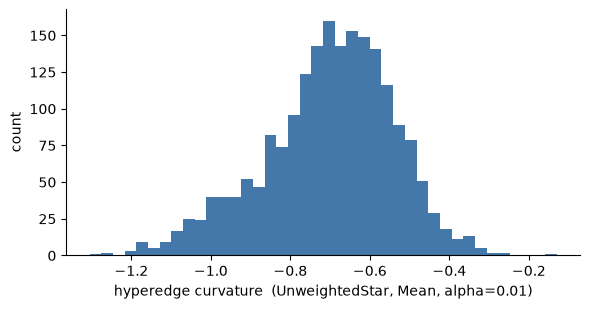

In [36]:
import statistics

print(f"n       = {len(curvatures)}")
print(f"min     = {min(curvatures):.4f}")
print(f"median  = {statistics.median(curvatures):.4f}")
print(f"mean    = {statistics.fmean(curvatures):.4f}")
print(f"max     = {max(curvatures):.4f}")
if len(curvatures) > 1:
    print(f"stdev   = {statistics.stdev(curvatures):.4f}")

n_nan = sum(c != c for c in curvatures)
if n_nan:
    print(f"warning: {n_nan} NaN curvature(s)")

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6, 3.2))
    ax.hist([c for c in curvatures if c == c], bins=40, color="#4477aa")
    ax.set_xlabel(f"hyperedge curvature  ({DISPERSION}, {AGGREGATION}, alpha={ALPHA})")
    ax.set_ylabel("count")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("(matplotlib not installed — skipping histogram)")